In [2]:
from classy import Class
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# primarily CDM universe
params_cdm = {
    "output": "mTk, mPk",     # matter transfer function, power spectrum
    "P_k_max_h/Mpc": 10.0,    # max k on the  x-axis, usually 1 (?)
    "z_pk": 0.0,              # ?
    "h": 0.67,
   
   
    "Omega_b": 0.005,
    "Omega_cdm": 0.295, #so that they sum to 0.3, the total matter density parameter

    "A_s": 2.1e-9,            # primordial power spectrum amplitude. "how large" density fluctuations were initially    
    "n_s": 0.965,             # spectral index determining shape of primordial spectrum. =1 means scale-invariant, <1 means more power on large scales (small k)
    "YHe": 0.25,              # fraction of He mass over baryon mass. 
    "tau_reio": 0.06,         # ?
}

# add baryons (default universe)
params_b_cdm = {
    "output": "mTk, mPk",     
    "P_k_max_h/Mpc": 10.0,    
    "z_pk": 0.0,              
    "h": 0.67,

    "A_s": 2.1e-9,            
    "n_s": 0.965,                       
    "tau_reio": 0.06,         
}

# add a wdm particle
params_ncdm_cdm = {
    "output": "mTk, mPk",     
    "P_k_max_h/Mpc": 10.0,    
    "z_pk": 0.0,              
    "h": 0.67,

    "N_ncdm": 1,
    "Omega_ncdm": 0.1,
    # no ncdm; photons and N_ur included as default values

    "A_s": 2.1e-9,            
    "n_s": 0.965,                        
    "tau_reio": 0.06,         
}

# Initialize and run CLASS
cosmo_cdm = Class()
cosmo_cdm.set(params_cdm)
cosmo_cdm.compute()

cosmo_b_cdm = Class()
cosmo_b_cdm.set(params_b_cdm)
cosmo_b_cdm.compute()

cosmo_ncdm_cdm = Class()
cosmo_ncdm_cdm.set(params_ncdm_cdm)
cosmo_ncdm_cdm.compute()




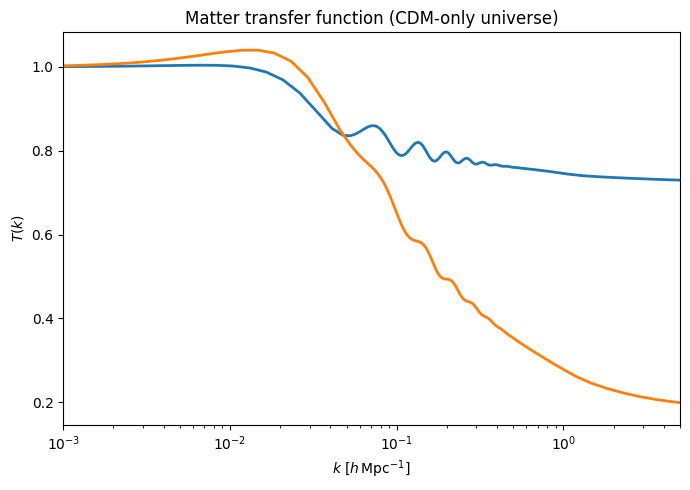

In [15]:
# Total matter transfer function at z=0
tk_cdm = cosmo_cdm.get_transfer(z=0)
ks_cdm = tk_cdm["k (h/Mpc)"]           
dtot_cdm = tk_cdm["d_tot"]     

tk_b_cdm = cosmo_b_cdm.get_transfer(z=0)
ks_b_cdm = tk_b_cdm["k (h/Mpc)"]           
dtot_b_cdm = tk_b_cdm["d_tot"]     

tk_ncdm_cdm = cosmo_ncdm_cdm.get_transfer(z=0)
ks_ncdm_cdm = tk_ncdm_cdm["k (h/Mpc)"]           
dtot_ncdm_cdm = tk_ncdm_cdm["d_tot"]  

#??
# Matter transfer function T(k):
T_cdm = np.abs(dtot_cdm) / ks_cdm**2 # on large scales delta_m ~ k^2 * T(k), so define T(k) = delta_m / k^2
T_cdm /= T_cdm[0] # normalize to 1 for the matter era entries

T_b_cdm = np.abs(dtot_b_cdm) / ks_b_cdm**2 # on large scales delta_m ~ k^2 * T(k), so define T(k) = delta_m / k^2
T_b_cdm /= T_b_cdm[0] # normalize to 1 for the matter era entries

T_ncdm_cdm = np.abs(dtot_ncdm_cdm) / ks_ncdm_cdm**2 # on large scales delta_m ~ k^2 * T(k), so define T(k) = delta_m / k^2
T_ncdm_cdm /= T_ncdm_cdm[0] # normalize to 1 for the matter era entries



# Plot
plt.figure(figsize=(7, 5))
plt.xscale("log")
plt.plot(ks_b_cdm, T_b_cdm / T_cdm, lw=2)
plt.plot(ks_ncdm_cdm, T_ncdm_cdm / T_cdm, lw=2)
plt.xlim(1e-3, 5)
plt.xlabel(r"$k \ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$T(k)$")
plt.title("Matter transfer function (CDM-only universe)")
plt.tight_layout()
plt.show()
